 # KNN

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [2]:
df = pd.read_csv(r"C:\Users\Dell\KNN method\BreastCancer.txt")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (699, 11)


,Id,Cl.thickness,Cell.size,Cell.shape,Marg.adhesion,Epith.c.size,Bare.nuclei,Bl.cromatin,Normal.nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1.0,3,1,1,0
1,1002945,5,4,4,5,7,10.0,3,2,1,0
2,1015425,3,1,1,1,2,2.0,3,1,1,0
3,1016277,6,8,8,1,3,4.0,3,7,1,0
4,1017023,4,1,1,3,2,1.0,3,1,1,0


In [3]:
df.info()
df.describe()
print("Missing values:")
print(df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())


<class 'pandas.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Id               699 non-null    int64  
 1   Cl.thickness     699 non-null    int64  
 2   Cell.size        699 non-null    int64  
 3   Cell.shape       699 non-null    int64  
 4   Marg.adhesion    699 non-null    int64  
 5   Epith.c.size     699 non-null    int64  
 6   Bare.nuclei      683 non-null    float64
 7   Bl.cromatin      699 non-null    int64  
 8   Normal.nucleoli  699 non-null    int64  
 9   Mitoses          699 non-null    int64  
 10  Class            699 non-null    int64  
dtypes: float64(1), int64(10)
memory usage: 60.2 KB
Missing values:
Id                  0
Cl.thickness        0
Cell.size           0
Cell.shape          0
Marg.adhesion       0
Epith.c.size        0
Bare.nuclei        16
Bl.cromatin         0
Normal.nucleoli     0
Mitoses             0
Class               

In [5]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [6]:
df["Bare.nuclei"] = pd.to_numeric(
    df["Bare.nuclei"],
    errors="coerce"
)

print(df.isnull().sum())

Id                  0
Cl.thickness        0
Cell.size           0
Cell.shape          0
Marg.adhesion       0
Epith.c.size        0
Bare.nuclei        16
Bl.cromatin         0
Normal.nucleoli     0
Mitoses             0
Class               0
dtype: int64


In [7]:
df["Bare.nuclei"] = df["Bare.nuclei"].fillna(
    df["Bare.nuclei"].median()
)

In [8]:
X = df.drop("Class", axis=1)
y = df["Class"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

X shape: (699, 10)
y shape: (699,)

Features:
['Id', 'Cl.thickness', 'Cell.size', 'Cell.shape', 'Marg.adhesion', 'Epith.c.size', 'Bare.nuclei', 'Bl.cromatin', 'Normal.nucleoli', 'Mitoses']

Target:
Class


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (559, 10)
X_test : (140, 10)
y_train: (559,)
y_test : (140,)


In [33]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaler fitted successfully!")
print("Number of features:", X_train_scaled.shape[1])

Scaler fitted successfully!
Number of features: 10


In [11]:
k_values = [1, 3, 5, 7, 9, 11, 13, 15]

results = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    
    model.fit(X_train_scaled, y_train)
    
    y_pred = model.predict(X_test_scaled)
    
    accuracy = accuracy_score(y_test, y_pred)
    
    results.append({
        "K": k,
        "Accuracy": accuracy
    })

results_df = pd.DataFrame(results)

results_df

,K,Accuracy
0,1,0.928571
1,3,0.935714
2,5,0.942857
3,7,0.950000
4,9,0.957143
5,11,0.957143
6,13,0.957143
7,15,0.957143


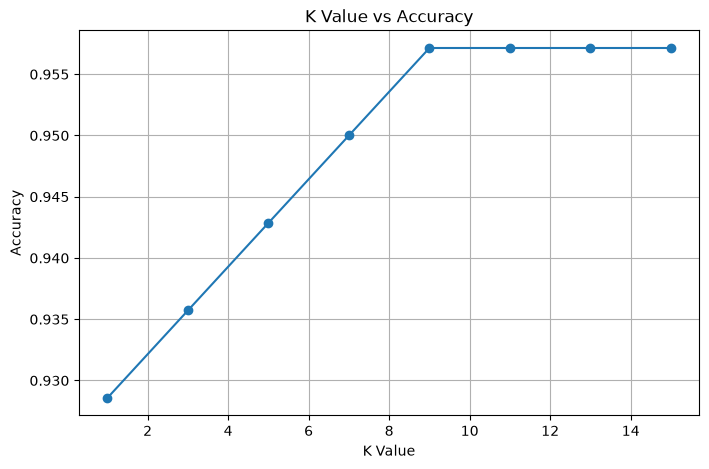

In [12]:
plt.figure(figsize=(8, 5))

plt.plot(
    results_df["K"],
    results_df["Accuracy"],
    marker="o"
)

plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("K Value vs Accuracy")
plt.grid(True)

plt.show()

In [13]:
best_k = results_df.loc[
    results_df["Accuracy"].idxmax(),
    "K"
]

best_accuracy = results_df["Accuracy"].max()

print("Best K:", int(best_k))
print("Best Accuracy:", round(best_accuracy, 4))

Best K: 9
Best Accuracy: 0.9571


In [34]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

print("KNN model trained successfully!")

KNN model trained successfully!


In [15]:
y_pred = knn_model.predict(X_test_scaled)

print("Predictions:")
print(y_pred[:20])

Predictions:
[1 0 0 0 1 1 0 0 0 0 1 1 1 0 1 1 1 0 0 0]


In [16]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 4))
print("Accuracy %:", round(accuracy * 100, 2), "%")

Accuracy: 0.9571
Accuracy %: 95.71 %


In [17]:
precision = precision_score(y_test, y_pred)

print("Precision:", round(precision, 4))

Precision: 0.9375


In [18]:
precision = precision_score(y_test, y_pred)

print("Precision:", round(precision, 4))

Precision: 0.9375


In [19]:
recall = recall_score(y_test, y_pred)

print("Recall:", round(recall, 4))

Recall: 0.9375


In [20]:
f1 = f1_score(y_test, y_pred)

print("F1 Score:", round(f1, 4))

F1 Score: 0.9375


In [21]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[89  3]
 [ 3 45]]


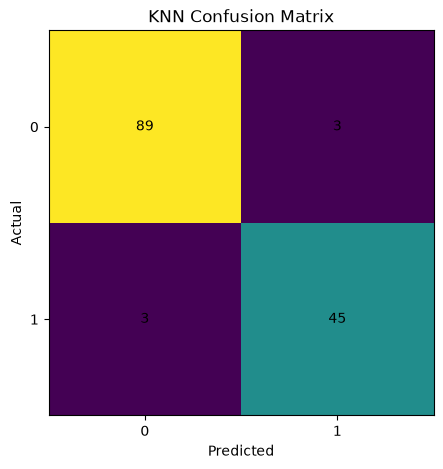

In [22]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1])
plt.yticks([0, 1])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

In [23]:
print(classification_report(
    y_test,
    y_pred
))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97        92
           1       0.94      0.94      0.94        48

    accuracy                           0.96       140
   macro avg       0.95      0.95      0.95       140
weighted avg       0.96      0.96      0.96       140



In [24]:
metrics = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1
}

metrics_df = pd.DataFrame(
    metrics.items(),
    columns=["Metric", "Score"]
)

metrics_df

,Metric,Score
0,Accuracy,0.957143
1,Precision,0.937500
2,Recall,0.937500
3,F1 Score,0.937500


In [28]:
X = df.drop(["Id", "Class"], axis=1)
y = df["Class"]

print("Features:")
print(X.columns.tolist())

Features:
['Cl.thickness', 'Cell.size', 'Cell.shape', 'Marg.adhesion', 'Epith.c.size', 'Bare.nuclei', 'Bl.cromatin', 'Normal.nucleoli', 'Mitoses']


In [30]:
new_customer = pd.DataFrame({
    "Cl.thickness": [5],
    "Cell.size": [2],
    "Cell.shape": [2],
    "Marg.adhesion": [3],
    "Epith.c.size": [2],
    "Bare.nuclei": [2],
    "Bl.cromatin": [3],
    "Normal.nucleoli": [1],
    "Mitoses": [1]
})

In [31]:
new_customer = new_customer[X.columns]

print(new_customer)

   Cl.thickness  Cell.size  Cell.shape  Marg.adhesion  Epith.c.size  \
0             5          2           2              3             2   

   Bare.nuclei  Bl.cromatin  Normal.nucleoli  Mitoses  
0            2            3                1        1  


In [36]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

# Remove ID and target
X = df.drop(columns=["Id", "Class"])
y = df["Class"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Fresh scaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fresh KNN model
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

print("Model trained successfully!")
print("Training features:", X.columns.tolist())
print("Number of features:", X.shape[1])

Model trained successfully!
Training features: ['Cl.thickness', 'Cell.size', 'Cell.shape', 'Marg.adhesion', 'Epith.c.size', 'Bare.nuclei', 'Bl.cromatin', 'Normal.nucleoli', 'Mitoses']
Number of features: 9


In [37]:
new_customer_scaled = scaler.transform(
    new_customer.to_numpy()
)

prediction = knn_model.predict(new_customer_scaled)

print("Predicted Class:", prediction[0])

Predicted Class: 0


c:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [38]:
if prediction[0] == 1:
    print("Customer Class: 1")
else:
    print("Customer Class: 0")

Customer Class: 0


In [39]:
probability = knn_model.predict_proba(new_customer_scaled)

print("Class 0 Probability:", round(probability[0][0], 4))
print("Class 1 Probability:", round(probability[0][1], 4))

Class 0 Probability: 1.0
Class 1 Probability: 0.0


In [40]:
import joblib

joblib.dump(knn_model, "knn_model.pkl")
joblib.dump(scaler, "standard_scaler.pkl")

print("KNN model saved successfully!")
print("Scaler saved successfully!")

KNN model saved successfully!
Scaler saved successfully!
